# Part B: Fine-Tuning

## Importing Libraries

In [ ]:
# Data Handling and Preprocessing
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import random
import os


# Image and Visualisation
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

# PyTorch and Torchvision
import torch
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)

## Loading Data

### Obtaining labels for each class

In [ ]:
with open("/kaggle/input/food-101/food-101/meta/classes.txt", "r") as f:
    class_names = f.read().splitlines()

# Create mapping from index to class name
label_to_class = {idx: class_name for idx, class_name in enumerate(class_names)}
label_to_class

{0: 'apple_pie',
 1: 'baby_back_ribs',
 2: 'baklava',
 3: 'beef_carpaccio',
 4: 'beef_tartare',
 5: 'beet_salad',
 6: 'beignets',
 7: 'bibimbap',
 8: 'bread_pudding',
 9: 'breakfast_burrito',
 10: 'bruschetta',
 11: 'caesar_salad',
 12: 'cannoli',
 13: 'caprese_salad',
 14: 'carrot_cake',
 15: 'ceviche',
 16: 'cheesecake',
 17: 'cheese_plate',
 18: 'chicken_curry',
 19: 'chicken_quesadilla',
 20: 'chicken_wings',
 21: 'chocolate_cake',
 22: 'chocolate_mousse',
 23: 'churros',
 24: 'clam_chowder',
 25: 'club_sandwich',
 26: 'crab_cakes',
 27: 'creme_brulee',
 28: 'croque_madame',
 29: 'cup_cakes',
 30: 'deviled_eggs',
 31: 'donuts',
 32: 'dumplings',
 33: 'edamame',
 34: 'eggs_benedict',
 35: 'escargots',
 36: 'falafel',
 37: 'filet_mignon',
 38: 'fish_and_chips',
 39: 'foie_gras',
 40: 'french_fries',
 41: 'french_onion_soup',
 42: 'french_toast',
 43: 'fried_calamari',
 44: 'fried_rice',
 45: 'frozen_yogurt',
 46: 'garlic_bread',
 47: 'gnocchi',
 48: 'greek_salad',
 49: 'grilled_chees

### Reading Train and Test Image Paths

In [ ]:
# Read train & test image paths
with open("/kaggle/input/food-101/food-101/meta/train.txt", "r") as f:
    train_image_ids = f.read().splitlines()

with open("/kaggle/input/food-101/food-101/meta/test.txt", "r") as f:
    test_image_ids = f.read().splitlines()

# Extract labels (folder names) from image paths
y_data = [image_id.split("/")[0] for image_id in train_image_ids]  # Labels for training set
y_test = [image_id.split("/")[0] for image_id in test_image_ids]   # Labels for test set

# Construct full image paths
X_data = [f"/kaggle/input/food-101/food-101/images/{image_id}.jpg" for image_id in train_image_ids]  # Train image paths
X_test = [f"/kaggle/input/food-101/food-101/images/{image_id}.jpg" for image_id in test_image_ids]   # Test image paths

# Print samples
print("First 5 image paths (X_data):", X_data[:5])
print("First 5 labels (y_data):", y_data[:5])
print("First 5 image paths (X_test):", X_test[:5])
print("First 5 labels (y_test):", y_test[:5])


First 5 image paths (X_data): ['/kaggle/input/food-101/food-101/images/apple_pie/1005649.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1014775.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1026328.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1028787.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1043283.jpg']
First 5 labels (y_data): ['apple_pie', 'apple_pie', 'apple_pie', 'apple_pie', 'apple_pie']
First 5 image paths (X_test): ['/kaggle/input/food-101/food-101/images/apple_pie/1011328.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/101251.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1034399.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/103801.jpg', '/kaggle/input/food-101/food-101/images/apple_pie/1038694.jpg']
First 5 labels (y_test): ['apple_pie', 'apple_pie', 'apple_pie', 'apple_pie', 'apple_pie']


### Label Encoding

In [ ]:
# Fit LabelEncoder on ALL labels (train + test) to ensure consistency
label_encoder = LabelEncoder()
label_encoder.fit(y_data + y_test)

# Encode labels
y_data_encoded = label_encoder.transform(y_data)
y_test_encoded = label_encoder.transform(y_test)

# Print label mapping
print("Label Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("First 5 Encoded Labels (y_data):", y_data_encoded[:5])
print("First 5 Encoded Labels (y_test):", y_test_encoded[:5])

Label Mapping: {'apple_pie': 0, 'baby_back_ribs': 1, 'baklava': 2, 'beef_carpaccio': 3, 'beef_tartare': 4, 'beet_salad': 5, 'beignets': 6, 'bibimbap': 7, 'bread_pudding': 8, 'breakfast_burrito': 9, 'bruschetta': 10, 'caesar_salad': 11, 'cannoli': 12, 'caprese_salad': 13, 'carrot_cake': 14, 'ceviche': 15, 'cheese_plate': 16, 'cheesecake': 17, 'chicken_curry': 18, 'chicken_quesadilla': 19, 'chicken_wings': 20, 'chocolate_cake': 21, 'chocolate_mousse': 22, 'churros': 23, 'clam_chowder': 24, 'club_sandwich': 25, 'crab_cakes': 26, 'creme_brulee': 27, 'croque_madame': 28, 'cup_cakes': 29, 'deviled_eggs': 30, 'donuts': 31, 'dumplings': 32, 'edamame': 33, 'eggs_benedict': 34, 'escargots': 35, 'falafel': 36, 'filet_mignon': 37, 'fish_and_chips': 38, 'foie_gras': 39, 'french_fries': 40, 'french_onion_soup': 41, 'french_toast': 42, 'fried_calamari': 43, 'fried_rice': 44, 'frozen_yogurt': 45, 'garlic_bread': 46, 'gnocchi': 47, 'greek_salad': 48, 'grilled_cheese_sandwich': 49, 'grilled_salmon': 50,

### Training, Validation and Testing Split

In [ ]:
# Split X_data into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_data_encoded, test_size=0.2, stratify=y_data_encoded, random_state=42
)

# Print dataset sizes
print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

Training set: 60600 images
Validation set: 15150 images
Test set: 25250 images


## Data Augmentation

In [ ]:
# Define transformations
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 (standard for CNNs)
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.RandomRotation(30),  # Random rotation
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Custom Class to Obtain Images and Labels From the Food101 Dataset

In [ ]:
# Define custom dataset class for Food101 to obtain images and labels
# This class will be used to load images and labels for training and validation
class Food101Dataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self): # Need it for DataLoader
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")  # Ensure it's RGB

        # Apply transformation
        if self.transform:
            image = self.transform(image)

        # Get label
        label = self.labels[idx]

        return image, label

In [ ]:
# Create datasets
train_dataset = Food101Dataset(X_train, y_train, transform=transform_train)
val_dataset = Food101Dataset(X_val, y_val, transform=transform_test)
test_dataset = Food101Dataset(X_test, y_test_encoded, transform=transform_test)

## Setup Dataloaders

In [ ]:
# Define batch size
batch_size = 128

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check a sample batch
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels:", labels[:5])

Batch image shape: torch.Size([128, 3, 224, 224])
Batch labels: tensor([13,  5,  1, 66, 89])


In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load MobileNet V3 Large

In [ ]:
# Load pretrained models
mobilenet_v3 = models.mobilenet_v3_large(pretrained=True)  # MobileNet V3 (Large version)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 91.6MB/s]


### MobileNet V3 Architecture

In [ ]:
print(mobilenet_v3)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

## Experiment 1: Unfreezing Last Two Blocks

Rationale: Unfreezing the last two blocks of MobileNetV3 allows the model to adapt high-level feature representations to the specific characteristics of the Food101 dataset

### Last Block

In [ ]:
mobilenet_v3.features[-1].parameters

<bound method Module.parameters of Conv2dNormActivation(
  (0): Conv2d(160, 960, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(960, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  (2): Hardswish()
)>

### Second Last Block

In [ ]:
mobilenet_v3.features[-2].parameters

<bound method Module.parameters of InvertedResidual(
  (block): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(160, 960, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(960, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(960, 960, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=960, bias=False)
      (1): BatchNorm2d(960, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (2): SqueezeExcitation(
      (avgpool): AdaptiveAvgPool2d(output_size=1)
      (fc1): Conv2d(960, 240, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(240, 960, kernel_size=(1, 1), stride=(1, 1))
      (activation): ReLU()
      (scale_activation): Hardsigmoid()
    )
    (3): Conv2dNormActivation(
      (0): Conv2d(960, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(160, eps=0.001, momentum=0.01,

### Unfreeze last 2 blocks

In [ ]:
# Freeze all pre-trained layers
for param in mobilenet_v3.parameters():
    param.requires_grad = False

# Unfreeze the last two blocks
for param in mobilenet_v3.features[-1].parameters():
    param.requires_grad = True

for param in mobilenet_v3.features[-2].parameters():
    param.requires_grad = True

### Replace Classifier

In [ ]:
# MobileNet V3 Last Layer
# Replace the final fully connected layer (classifier) with a new head
mobilenet_v3.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3.classifier[3].in_features, 512),  # First fully connected layer
    nn.ReLU(),                                              # Activation
    nn.Dropout(0.2),                                         # Dropout for regularization
    nn.Linear(512, 256),                                     # Second fully connected layer
    nn.ReLU(),                                              # Activation
    nn.Linear(256, 101)                                      # Final output layer for 101 classes
)
mobilenet_v3_exp_1 = mobilenet_v3

### Adjust Learning Rate

In [ ]:
# Use a lower learning rate for pre-trained layers and a higher one for the new classifier head
optimizer_mobilenet = optim.Adam([
    {'params': mobilenet_v3_exp_1.features.parameters(), 'lr': 1e-5},  # Low learning rate for the base model
    {'params': mobilenet_v3_exp_1.classifier.parameters(), 'lr': 1e-3}  # Higher learning rate for the new head
])

# Criterion
criterion = nn.CrossEntropyLoss()


### Custom Callback Function

The following custom callback function was adapted from William So's 2025 Lab 4, Exercise 3 notebook.

In [ ]:
class CustomCallback:
    def __init__(self, early_stop_patience=5, reduce_lr_factor=0.2, reduce_lr_patience=3, reduce_lr_min_lr=0.0000001, checkpoint_path='checkpoint.pth', log_dir='logs'):

        # Parameters for early stopping and learning rate reduction
        self.early_stop_patience = early_stop_patience    # Patience for early stopping
        self.reduce_lr_factor = reduce_lr_factor          # Factor by which to reduce learning rate
        self.reduce_lr_patience = reduce_lr_patience      # Patience for reducing learning rate
        self.reduce_lr_min_lr = reduce_lr_min_lr          # Minimum learning rate
        self.checkpoint_path = checkpoint_path            # Path to save model checkpoints
        # self.log_dir = log_dir  # Directory for logging (if needed)

        self.early_stop_counter = 0                       # Counter to track epochs without improvement
        self.best_val_loss = float('inf')                 # Best validation loss

        self.optimizer = None                             # Placeholder for the optimizer
        self.scheduler = None                             # Placeholder for the LR scheduler

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer                        # Set optimizer for training

    def on_epoch_end(self, epoch, val_loss):
        # Early Stopping: Check if the validation loss improved
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.early_stop_counter = 0                   # Reset counter if improvement is seen
        else:
            self.early_stop_counter += 1                  # Increment counter if no improvement

        # Trigger early stopping if no improvement for a defined number of epochs
        if self.early_stop_counter >= self.early_stop_patience:
            print("Early stopping triggered!")
            return True                                   #  Return True to signal stopping training

        # Adjust the learning rate if a plateau in validation loss is detected
        if self.scheduler is not None:
            self.scheduler.step(val_loss)                 # Adjust learning rate based on validation loss

        return False  # Continue training if conditions are not met

    def on_train_begin(self):
        # Initialize the ReduceLROnPlateau scheduler with the optimizer and parameters.
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=self.reduce_lr_factor,patience=self.reduce_lr_patience, min_lr=self.reduce_lr_min_lr)

    def on_train_end(self):
        pass                  # Additional cleanup can be done here if needed

    def set_model(self, model):
        self.model = model    # Store the model reference

In [ ]:
# Define a function to save the model
def save_model_at_end(model, save_path):
    torch.save(model.state_dict(), save_path)
    print(f"Model saved at {save_path}")

In [ ]:
# Move models to device
mobilenet_v3_exp_1.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(mobilenet_v3_exp_1)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training and Evaluation: Mobilenet v3

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

save_path = 'mobilenet_v3_exp_1.pth'

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_exp_1.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_exp_1(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    if epoch == num_epochs - 1:  # Save at the end of the last epoch
        save_model_at_end(mobilenet_v3_exp_1, save_path)

    # Validation
    mobilenet_v3_exp_1.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = mobilenet_v3_exp_1(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 2.6966, Train Accuracy: 0.3466, Val Loss: 2.1208, Val Accuracy: 0.4677


Epoch [2/10], Train Loss: 2.0661, Train Accuracy: 0.4749, Val Loss: 1.9754, Val Accuracy: 0.4996


Epoch [3/10], Train Loss: 1.9079, Train Accuracy: 0.5089, Val Loss: 1.8935, Val Accuracy: 0.5173


Epoch [4/10], Train Loss: 1.7876, Train Accuracy: 0.5352, Val Loss: 1.8586, Val Accuracy: 0.5262


Epoch [5/10], Train Loss: 1.6940, Train Accuracy: 0.5562, Val Loss: 1.8267, Val Accuracy: 0.5360


...

Epoch [7/10], Train Loss: 1.5595, Train Accuracy: 0.5831, Val Loss: 1.7763, Val Accuracy: 0.5506


Epoch [8/10], Train Loss: 1.5023, Train Accuracy: 0.5980, Val Loss: 1.7629, Val Accuracy: 0.5558


Epoch [9/10], Train Loss: 1.4513, Train Accuracy: 0.6069, Val Loss: 1.7673, Val Accuracy: 0.5485


Model saved at mobilenet_v3_exp_1.pth


Epoch [10/10], Train Loss: 1.4025, Train Accuracy: 0.6175, Val Loss: 1.7636, Val Accuracy: 0.5568


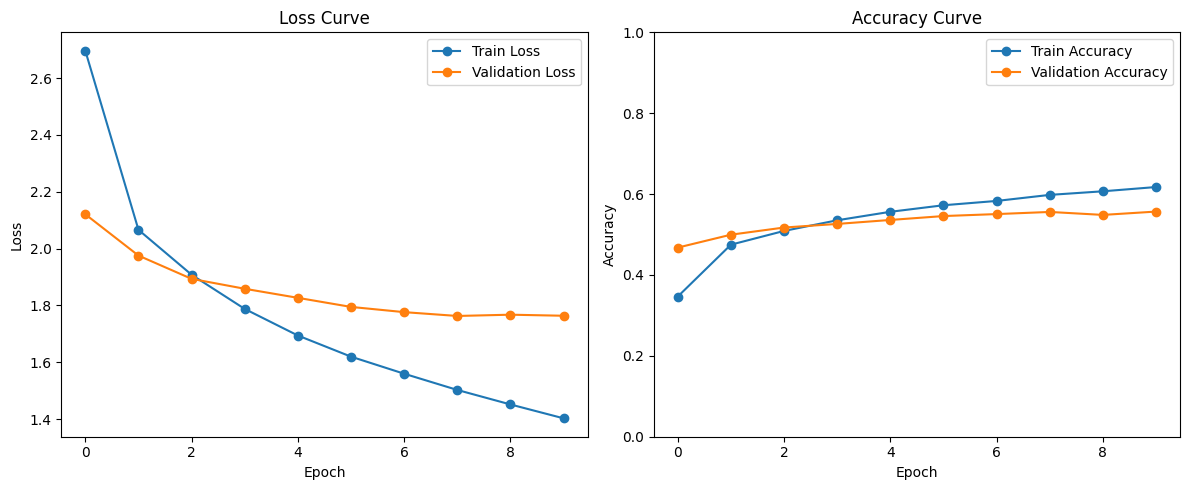

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

## Experiment 2: Unfreeze Last 4 Blocks

Rationale: Unfreezing two blocks improved overall performance, suggesting that fine-tuning deeper layers helps the model better adapt to the new task. Therefore, explore whether unfreezing four blocks will further improve performance by allowing more layers to learn dataset-specific features.

In [ ]:
# Load MobileNet V3 model
mobilenet_v3_exp_2 = models.mobilenet_v3_large(pretrained=True)

### Unfreeze the last 4 blocks

In [ ]:
# Freeze all pre-trained layers
for param in mobilenet_v3_exp_2.parameters():
    param.requires_grad = False

# UnFreeze last 4 Blocks
for i in [-4, -3, -2, -1]:
    for param in mobilenet_v3_exp_2.features[i].parameters():
        param.requires_grad = True

### Replace Classifier

In [ ]:
# MobileNet V3 Last Layer
# Replace the final fully connected layer (classifier) with a new head
mobilenet_v3_exp_2.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3_exp_2.classifier[3].in_features, 512),  # First fully connected layer
    nn.ReLU(),                                              # Activation
    nn.Dropout(0.2),                                         # Dropout for regularization
    nn.Linear(512, 256),                                     # Second fully connected layer
    nn.ReLU(),                                              # Activation
    nn.Linear(256, 101)                                      # Final output layer for 101 classes
)

### Adjust Learning Rate

In [ ]:
# Use a lower learning rate for pre-trained layers and a higher one for the new classifier head
optimizer_mobilenet = optim.Adam([
    {'params': mobilenet_v3_exp_2.features[13:].parameters(), 'lr': 1e-5},  # Low learning rate for unfrozen layers
    {'params': mobilenet_v3_exp_2.classifier.parameters(), 'lr': 1e-3}  # Higher learning rate for the new head
])

# Criterion
criterion = nn.CrossEntropyLoss()

In [ ]:
# Move models to device
mobilenet_v3_exp_2.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(mobilenet_v3_exp_2)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training and Validation

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

save_path = 'mobilenet_v3_exp_2.pth'

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_exp_2.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_exp_2(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    if epoch == num_epochs - 1:  # Save at the end of the last epoch
        save_model_at_end(mobilenet_v3_exp_2, save_path)

    # Validation
    mobilenet_v3_exp_2.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = mobilenet_v3_exp_2(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 2.6246, Train Accuracy: 0.3631, Val Loss: 1.9938, Val Accuracy: 0.4974


Epoch [2/10], Train Loss: 1.9149, Train Accuracy: 0.5081, Val Loss: 1.7782, Val Accuracy: 0.5466


Epoch [3/10], Train Loss: 1.7092, Train Accuracy: 0.5534, Val Loss: 1.7035, Val Accuracy: 0.5653


Epoch [4/10], Train Loss: 1.5628, Train Accuracy: 0.5890, Val Loss: 1.6541, Val Accuracy: 0.5766


Epoch [5/10], Train Loss: 1.4568, Train Accuracy: 0.6125, Val Loss: 1.6039, Val Accuracy: 0.5903


...

Epoch [7/10], Train Loss: 1.2882, Train Accuracy: 0.6484, Val Loss: 1.5779, Val Accuracy: 0.5995


Epoch [8/10], Train Loss: 1.2239, Train Accuracy: 0.6631, Val Loss: 1.5487, Val Accuracy: 0.6079


Epoch [9/10], Train Loss: 1.1667, Train Accuracy: 0.6742, Val Loss: 1.5397, Val Accuracy: 0.6155


Model saved at mobilenet_v3_exp_2.pth


Epoch [10/10], Train Loss: 1.1179, Train Accuracy: 0.6871, Val Loss: 1.5681, Val Accuracy: 0.6058


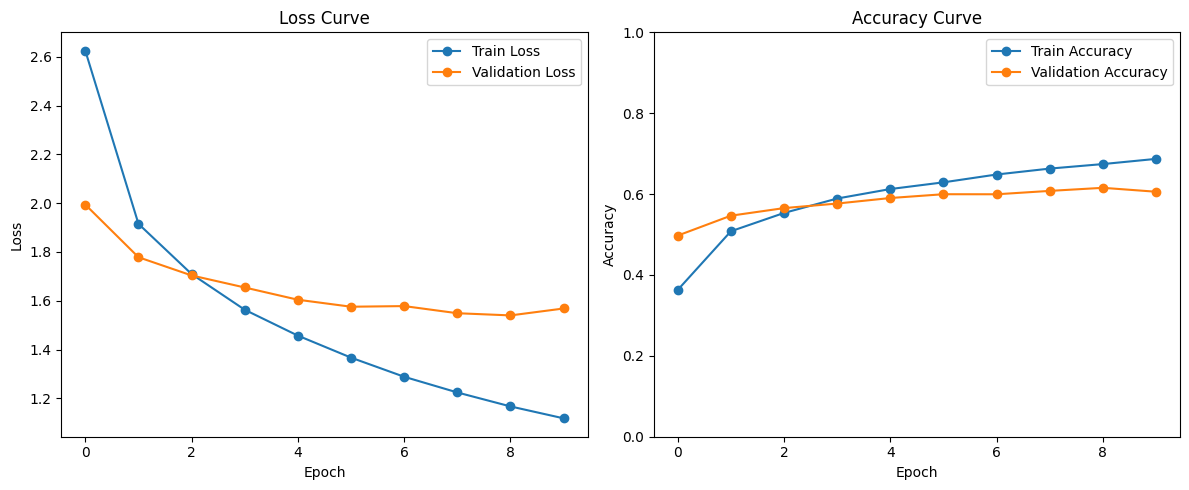

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

## Experiment 3: Batch Normalisation

Rationale: Unfreezing four blocks improved performance even further. However, there are potential signs of overfitting from the increasing differences in accuracies between training and validation. To address this, Batch Normalisation will be applied to help stabilise training and reduce overfitting.

In [ ]:
# Load MobileNet V3 model
mobilenet_v3_exp_3 = models.mobilenet_v3_large(pretrained=True)

### Unfreeze the last 4 blocks

In [ ]:
# Freeze all pre-trained layers
for param in mobilenet_v3_exp_3.parameters():
    param.requires_grad = False

# UnFreeze last 4 Blocks
for i in [-4, -3, -2, -1]:
    for param in mobilenet_v3_exp_3.features[i].parameters():
        param.requires_grad = True

### Replace Classifier

In [ ]:
# MobileNet V3 Last Layer with Batch Normalisation
mobilenet_v3_exp_3.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3_exp_3.classifier[3].in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 101)
)

### Adjust Learning Rate

In [ ]:
# Use a lower learning rate for pre-trained layers and a higher one for the new classifier head
optimizer_mobilenet = optim.Adam([
    {'params': mobilenet_v3_exp_3.features[13:].parameters(), 'lr': 1e-5},  # Low learning rate for unfrozen layers
    {'params': mobilenet_v3_exp_3.classifier.parameters(), 'lr': 1e-3}  # Higher learning rate for the new head
])

# Criterion
criterion = nn.CrossEntropyLoss()

In [ ]:
# Move models to device
mobilenet_v3_exp_3.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(mobilenet_v3_exp_3)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training and Validation

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

save_path = 'mobilenet_v3_exp_3.pth'

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_exp_3.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_exp_3(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    if epoch == num_epochs - 1:  # Save at the end of the last epoch
        save_model_at_end(mobilenet_v3_exp_3, save_path)

    # Validation
    mobilenet_v3_exp_3.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = mobilenet_v3_exp_3(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 2.6430, Train Accuracy: 0.3789, Val Loss: 1.9480, Val Accuracy: 0.5075


Epoch [2/10], Train Loss: 1.9170, Train Accuracy: 0.5118, Val Loss: 1.7655, Val Accuracy: 0.5446


Epoch [3/10], Train Loss: 1.7000, Train Accuracy: 0.5548, Val Loss: 1.6755, Val Accuracy: 0.5673


Epoch [4/10], Train Loss: 1.5664, Train Accuracy: 0.5844, Val Loss: 1.6172, Val Accuracy: 0.5825


Epoch [5/10], Train Loss: 1.4673, Train Accuracy: 0.6095, Val Loss: 1.5609, Val Accuracy: 0.5976


...

Epoch [7/10], Train Loss: 1.3114, Train Accuracy: 0.6433, Val Loss: 1.5019, Val Accuracy: 0.6165


Epoch [8/10], Train Loss: 1.2386, Train Accuracy: 0.6597, Val Loss: 1.4784, Val Accuracy: 0.6209


Epoch [9/10], Train Loss: 1.1853, Train Accuracy: 0.6712, Val Loss: 1.4835, Val Accuracy: 0.6232


Model saved at mobilenet_v3_exp_3.pth


Epoch [10/10], Train Loss: 1.1345, Train Accuracy: 0.6826, Val Loss: 1.4718, Val Accuracy: 0.6244


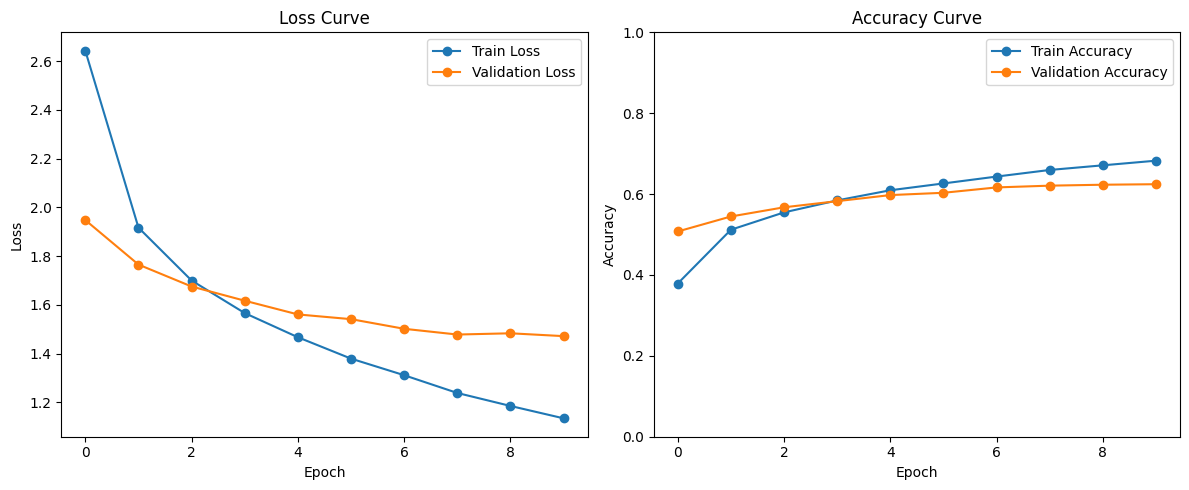

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

## Experiment 4: Unfreezing 6 Blocks

Rationale: Here, last six blocks will be unfreezed to explore whether this additional fine-tuning can further improve the model’s performance by allowing even deeper layers to adjust to the dataset’s specific features.

In [ ]:
# Load MobileNet V3 model
mobilenet_v3_exp_4 = models.mobilenet_v3_large(pretrained=True)

### Unfreeze last 6 blocks

In [ ]:
# Freeze all pre-trained layers
for param in mobilenet_v3_exp_4.parameters():
    param.requires_grad = False

# UnFreeze last 4 blocks
for i in [-6, -5, -4, -3, -2, -1]:
    for param in mobilenet_v3_exp_4.features[i].parameters():
        param.requires_grad = True

### Replace classifier

In [ ]:
# MobileNet V3 Last Layer with Batch Normalisation
mobilenet_v3_exp_4.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3_exp_4.classifier[3].in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 101)
)

### Adjust Learning Rate

In [ ]:
# Use a lower learning rate for pre-trained layers and a higher one for the new classifier head
optimizer_mobilenet = optim.Adam([
    {'params': mobilenet_v3_exp_4.features[11:].parameters(), 'lr': 1e-5},  # Low learning rate for unfrozen layers
    {'params': mobilenet_v3_exp_4.classifier.parameters(), 'lr': 1e-3}  # Higher learning rate for the new head
])

# Criterion
criterion = nn.CrossEntropyLoss()

In [ ]:
# Move models to device
mobilenet_v3_exp_4.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(mobilenet_v3_exp_4)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training and Validation

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

save_path = 'mobilenet_v3_exp_4.pth'

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_exp_4.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_exp_4(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    if epoch == num_epochs - 1:  # Save at the end of the last epoch
        save_model_at_end(mobilenet_v3_exp_4, save_path)

    # Validation
    mobilenet_v3_exp_4.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = mobilenet_v3_exp_4(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 2.5722, Train Accuracy: 0.3935, Val Loss: 1.8436, Val Accuracy: 0.5306


Epoch [2/10], Train Loss: 1.7748, Train Accuracy: 0.5455, Val Loss: 1.6238, Val Accuracy: 0.5785


Epoch [3/10], Train Loss: 1.5502, Train Accuracy: 0.5927, Val Loss: 1.5139, Val Accuracy: 0.6073


Epoch [4/10], Train Loss: 1.3980, Train Accuracy: 0.6290, Val Loss: 1.4490, Val Accuracy: 0.6250


Epoch [5/10], Train Loss: 1.2866, Train Accuracy: 0.6515, Val Loss: 1.3914, Val Accuracy: 0.6399


...

Epoch [7/10], Train Loss: 1.1217, Train Accuracy: 0.6907, Val Loss: 1.3443, Val Accuracy: 0.6537


Epoch [8/10], Train Loss: 1.0529, Train Accuracy: 0.7051, Val Loss: 1.3339, Val Accuracy: 0.6553


Epoch [9/10], Train Loss: 0.9898, Train Accuracy: 0.7201, Val Loss: 1.3286, Val Accuracy: 0.6594


Model saved at mobilenet_v3_exp_4.pth


Epoch [10/10], Train Loss: 0.9324, Train Accuracy: 0.7331, Val Loss: 1.3175, Val Accuracy: 0.6632


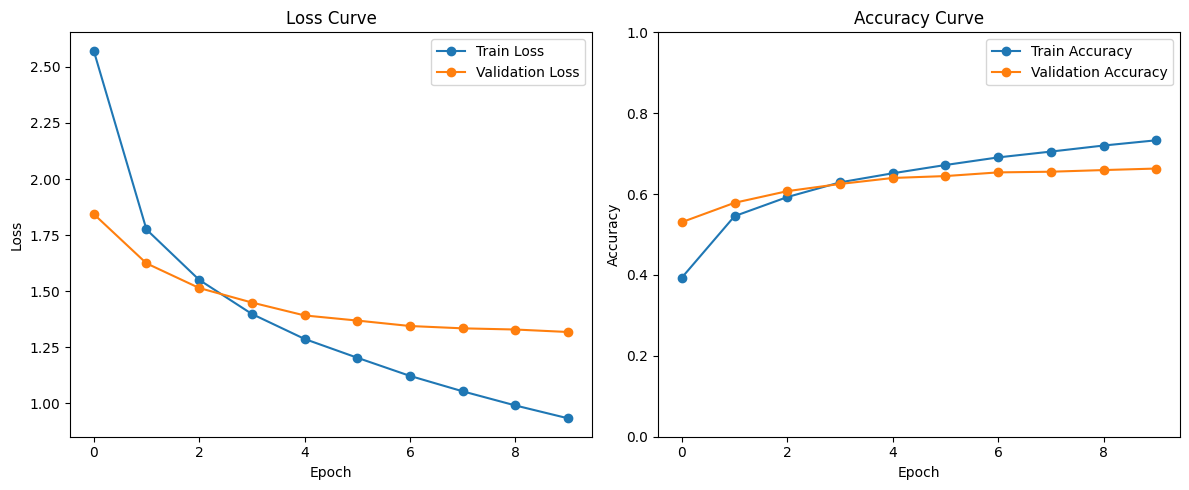

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

## Experiment 5: Label Smoothing

Rationale: Unfreezing six blocks resulted in improved performance, but once again, potential overfitting was observed. To counter this, label smoothing will be applied to for generalisation and reduce the impact of overfitting.

In [ ]:
# Load MobileNet V3 model
mobilenet_v3_exp_5 = models.mobilenet_v3_large(pretrained=True)

### Unfreeze last 6 blocks

In [ ]:
# Freeze all pre-trained layers
for param in mobilenet_v3_exp_5.parameters():
    param.requires_grad = False

# UnFreeze last 6 blocks
for i in [-6, -5, -4, -3, -2, -1]:
    for param in mobilenet_v3_exp_5.features[i].parameters():
        param.requires_grad = True

### Replace Classifier

In [ ]:
# MobileNet V3 Last Layer with Batch Normalisation
mobilenet_v3_exp_5.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3_exp_5.classifier[3].in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 101)
)

### Adjust Learning Rate

In [ ]:
# Use a lower learning rate for pre-trained layers and a higher one for the new classifier head
optimizer_mobilenet = optim.Adam([
    {'params': mobilenet_v3_exp_5.features[11:].parameters(), 'lr': 1e-5},  # Low learning rate for unfrozen layers
    {'params': mobilenet_v3_exp_5.classifier.parameters(), 'lr': 1e-3}  # Higher learning rate for the new head
])

# Criterion
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
# Move models to device
mobilenet_v3_exp_5.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(mobilenet_v3_exp_5)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training and Validation

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

save_path = 'mobilenet_v3_exp_5.pth'

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_exp_5.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_exp_5(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    if epoch == num_epochs - 1:  # Save at the end of the last epoch
        save_model_at_end(mobilenet_v3_exp_5, save_path)

    # Validation
    mobilenet_v3_exp_5.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = mobilenet_v3_exp_5(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/10], Train Loss: 2.9502, Train Accuracy: 0.3948, Val Loss: 2.4006, Val Accuracy: 0.5312


Epoch [2/10], Train Loss: 2.3349, Train Accuracy: 0.5441, Val Loss: 2.2160, Val Accuracy: 0.5825


Epoch [3/10], Train Loss: 2.1532, Train Accuracy: 0.5975, Val Loss: 2.1112, Val Accuracy: 0.6114


Epoch [4/10], Train Loss: 2.0364, Train Accuracy: 0.6300, Val Loss: 2.0515, Val Accuracy: 0.6329


Epoch [5/10], Train Loss: 1.9504, Train Accuracy: 0.6553, Val Loss: 2.0266, Val Accuracy: 0.6389


...

Epoch [7/10], Train Loss: 1.8195, Train Accuracy: 0.6933, Val Loss: 1.9713, Val Accuracy: 0.6582


Epoch [8/10], Train Loss: 1.7688, Train Accuracy: 0.7087, Val Loss: 1.9556, Val Accuracy: 0.6650


Epoch [9/10], Train Loss: 1.7187, Train Accuracy: 0.7264, Val Loss: 1.9458, Val Accuracy: 0.6682


Model saved at mobilenet_v3_exp_5.pth


Epoch [10/10], Train Loss: 1.6763, Train Accuracy: 0.7380, Val Loss: 1.9405, Val Accuracy: 0.6694


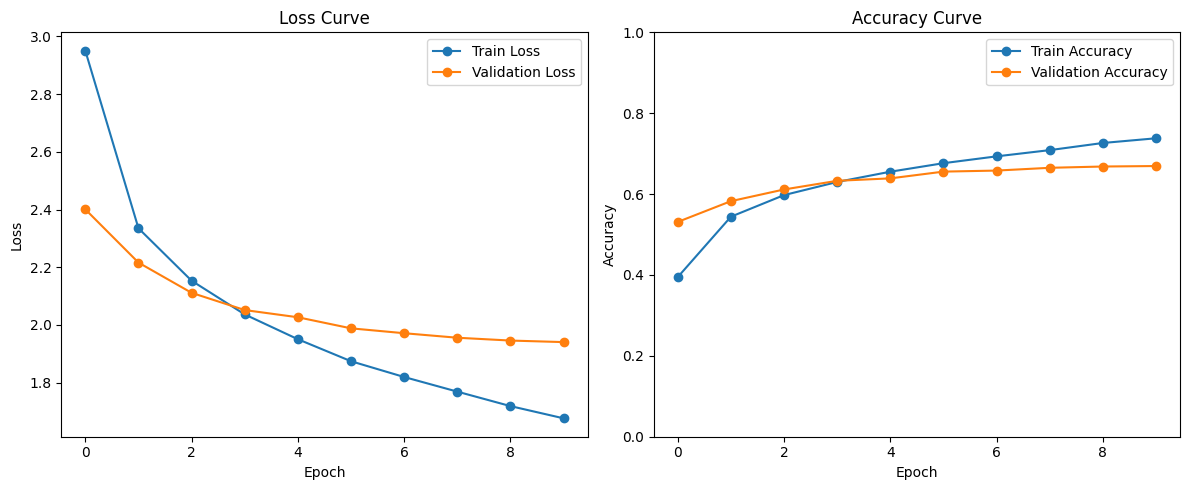

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

## Experiment 6: Final Model (More Training)

Rationale: For the final model, the number of epochs has been increased to 30 to allow sufficient time for the model to fully converge and achieve better performance.

In [ ]:
# Load MobileNet V3 model
mobilenet_v3_exp_6 = models.mobilenet_v3_large(pretrained=True)

### Unfreeze last 6 blocks

In [ ]:
# Freeze all pre-trained layers
for param in mobilenet_v3_exp_6.parameters():
    param.requires_grad = False

# UnFreeze last 6 blocks
for i in [-6, -5, -4, -3, -2, -1]:
    for param in mobilenet_v3_exp_6.features[i].parameters():
        param.requires_grad = True

### Replace Classifier

In [ ]:
# MobileNet V3 Last Layer with Batch Normalisation
mobilenet_v3_exp_6.classifier[3] = nn.Sequential(
    nn.Linear(mobilenet_v3_exp_6.classifier[3].in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 101)
)

### Adjust Learning Rate

In [ ]:
# Use a lower learning rate for pre-trained layers and a higher one for the new classifier head
optimizer_mobilenet = optim.Adam([
    {'params': mobilenet_v3_exp_6.features[11:].parameters(), 'lr': 1e-5},  # Low learning rate for unfrozen layers
    {'params': mobilenet_v3_exp_6.classifier.parameters(), 'lr': 1e-3}  # Higher learning rate for the new head
])

# Criterion
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
# Move models to device
mobilenet_v3_exp_6.to(device)

# Setting up the callback for GoogLeNet
callback_mobilenet = CustomCallback()
callback_mobilenet.set_optimizer(optimizer_mobilenet)
callback_mobilenet.set_model(mobilenet_v3_exp_6)

# Set the learning rate scheduler in the callback
lr_scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.1, patience=3, min_lr=1e-6)

### Training and Validation

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

save_path = 'mobilenet_v3_exp_6.pth'

# Training loop
num_epochs = 30                     # Increased number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_exp_6.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    # Use tqdm for progress bar in training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer_mobilenet.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_exp_6(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer_mobilenet.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    if epoch == num_epochs - 1:  # Save at the end of the last epoch
        save_model_at_end(mobilenet_v3_exp_6, save_path)

    # Validation
    mobilenet_v3_exp_6.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        # Use tqdm for progress bar in validation loop
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = mobilenet_v3_exp_6(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if callback_mobilenet.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')


Epoch [1/30], Train Loss: 2.9408, Train Accuracy: 0.4017, Val Loss: 2.3823, Val Accuracy: 0.5351


Epoch [2/30], Train Loss: 2.3306, Train Accuracy: 0.5461, Val Loss: 2.2039, Val Accuracy: 0.5848


Epoch [3/30], Train Loss: 2.1493, Train Accuracy: 0.5964, Val Loss: 2.1122, Val Accuracy: 0.6106


Epoch [4/30], Train Loss: 2.0351, Train Accuracy: 0.6300, Val Loss: 2.0643, Val Accuracy: 0.6249


Epoch [5/30], Train Loss: 1.9547, Train Accuracy: 0.6546, Val Loss: 2.0227, Val Accuracy: 0.6389


...

Epoch [22/30], Train Loss: 1.3489, Train Accuracy: 0.8533, Val Loss: 1.9001, Val Accuracy: 0.6917


Epoch [23/30], Train Loss: 1.3404, Train Accuracy: 0.8577, Val Loss: 1.8982, Val Accuracy: 0.6912


Epoch [24/30], Train Loss: 1.3374, Train Accuracy: 0.8587, Val Loss: 1.8982, Val Accuracy: 0.6917


Epoch [25/30], Train Loss: 1.3332, Train Accuracy: 0.8594, Val Loss: 1.9025, Val Accuracy: 0.6912


Early stopping triggered!


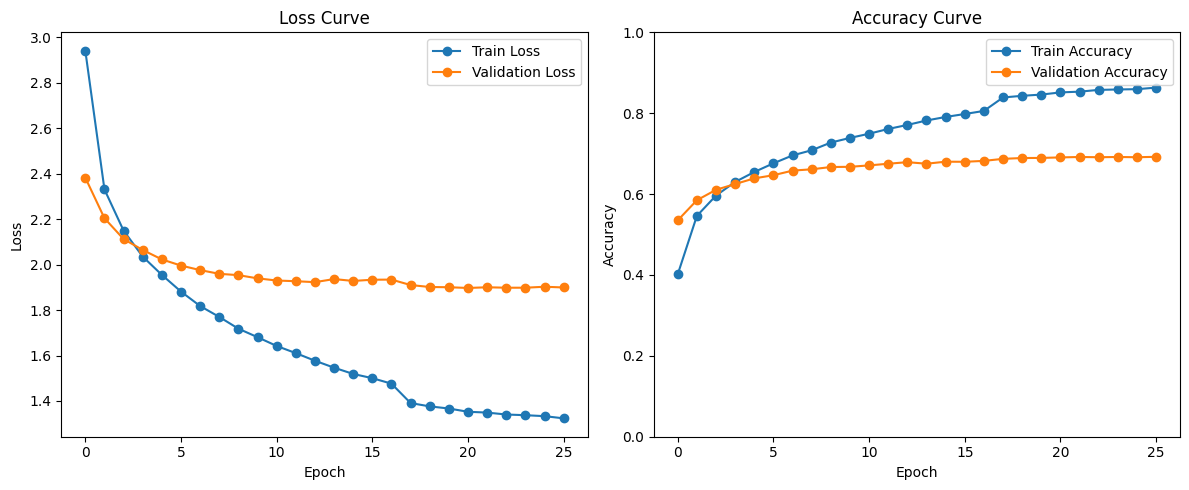

In [ ]:
# Plot Loss Curve and Accuracy curve
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

### Final Model Testing

In [ ]:
# Set the model to evaluation mode and disable gradients for testing.
mobilenet_v3_exp_6.eval()
test_correct = 0          # Counter for correct predictions in testing
test_total = 0            # Total test samples processed
test_running_loss = 0.0   # Accumulator for test loss

with torch.no_grad():                                           # Turn off gradients during evaluation
    for inputs, labels in test_loader:                          # Iterate through test data
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU
        outputs = mobilenet_v3_exp_6(inputs)                           # Get model predictions

        if isinstance(outputs, tuple):
            logits = outputs[0]                                 # Unpack logits from model outputs if necessary
        else:
            logits = outputs
        loss = criterion(logits, labels)                        # Calculate loss

        test_running_loss += loss.item() * inputs.size(0)       # Update running test loss
        _, predicted = torch.max(logits, 1)                     # Get predicted labels
        test_total += labels.size(0)                            # Update total number of samples
        test_correct += (predicted == labels).sum().item()      # Update number of correctly predicted samples

# Calculate test loss and accuracy
test_loss = test_running_loss / len(test_loader.dataset)  # Average test loss
test_accuracy = test_correct / test_total                 # Test accuracy

# Print test results
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 1.6949, Test Accuracy: 0.7419


# Conclusion

In conclusion, the final model achieved a major improvement, with a test accuracy of 74.19% and a test loss of 1.6949, compared to the 55.43% accuracy of the Part A model without fine-tuning. By unfreezing additional layers, applying batch normalisation, label smoothing, and increasing the number of epochs, the model was able to better adapt to the dataset, resulting in a notable performance increase. 